In [7]:
import pandas as pd 
df = pd.read_csv('image_collection_clean.csv')
df['date-obs'] = pd.to_datetime(df['date-obs'])

/tmp/ipykernel_1064669/3471221146.py:2: DtypeWarning: Columns (10,41,69,76,91,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('image_collection_clean.csv')


In [4]:
# OGLE-2024-GD-0006 parece que venian con el Gaia23ddl que esta en ra: 15:23, y al pasar a 0006, no se modifico el 15 y en vez de 16:03 quedo 15:03
# OGLE-2024-GD-006 dos que quedaron con otro ra dec, 
# TOI3071 exoplaneta
# Gaia24bsj noche de tracking muy malo o mal set de coordenadas y son setpoints
# OGLE-2024-BLG-0592 idem gaiabjs
# OGLE-2024-DG-0016 noche de tracking muy malo o mal set de coordenadas
# OGLE2024DG0016 noche de tracking muy malo o mal set de coordenadas
# OGLE-2025-BLG-0675 bad_pointing
# el resto no tiene tantas imágenes para salvar, o son setpoints, o imágenes que tomaron algunos curiosos o favores como el exoplaneta TOI



test = df[(df["object"]=="NO_OBJECT") & (df["orig_obj"]=="OGLE-2025-BLG-0675")][["sep_arcsec","file", "ra", "dec", "wheel", "orig_obj", "time-obs", "date-obs","observer"]]
test



,sep_arcsec,file,ra,dec,wheel,orig_obj,time-obs,date-obs,observer
29978,4855.699684,OGLE-2025-BLG-0675i0001.fit,18:29:14.2,-23:36:38.7,(5) I,OGLE-2025-BLG-0675,00:20:00.149,2025-10-16,Buccino


In [5]:
df["orig_obj"].value_counts()

orig_obj
OGLE-2025-BLG-0675    3002
OGLE-2024-BLG-0592    2332
OGLE-2024-BLG-0674    1993
Gaia24bsi             1575
Gaia24bsj             1143
                      ... 
NGC2217                  1
WD0830-535               1
OGLE-24-GD               1
Set Point                1
NGC0092                  1
Name: count, Length: 116, dtype: int64

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from datetime import timedelta

priority_list = []

os.makedirs("plots", exist_ok=True)

for obj in [folder for folder in os.listdir("data/objetos") if not ".csv" in folder]:

    target_folder = f"data/objetos/{obj}"
    photo_files = [file for file in os.listdir(target_folder) if "photometry" in file]

    if len(photo_files) == 0:
        print(f"No photometry file for {obj}")
        continue

    mop_lc = pd.read_csv(f"{target_folder}/{photo_files[0]}")

    mop_lc = mop_lc[mop_lc["Filter"].isin(["OGLE_I", "G", "i(GaiaSP)", "V(GaiaSP)"])]

    if len(mop_lc) == 0:
        print(f"No valid filters for {obj}")
        continue

    mop_lc['Timestamp'] = pd.to_datetime(mop_lc['Timestamp'], errors="coerce")
    mop_lc['Magnitude'] = pd.to_numeric(mop_lc['Magnitude'], errors='coerce')
    mop_lc['Error'] = pd.to_numeric(mop_lc['Error'], errors='coerce')

    mop_lc = mop_lc.dropna(subset=["Timestamp", "Magnitude"])

    if len(mop_lc) < 5:
        print(f"Not enough points for {obj}")
        continue


    # --------- MÉTRICAS TEMPORALES Y FOTOMÉTRICAS ---------

    object_df = df[df["object"] == obj]

    if len(object_df) == 0:
        print(f"No images in df for {obj}")
        continue

    counts_series = (
        object_df.groupby(object_df["date-obs"].dt.date)
        .size()
        .sort_index()
    )

    n_total_images = counts_series.sum()
    n_distinct_nights = len(counts_series)

    # Fechas principales
    first_obs = object_df["date-obs"].min()
    last_obs = object_df["date-obs"].max()
    baseline_days = (last_obs - first_obs).days

    # Magnitudes
    mag_min = mop_lc["Magnitude"].min()
    mag_max = mop_lc["Magnitude"].max()

    # Fecha del pico (magnitud mínima)
    fecha_pico = mop_lc.loc[
        mop_lc["Magnitude"].idxmin(), "Timestamp"
    ].date()

    # --------- DISTRIBUCIÓN TEMPORAL ---------

    mop_sorted = mop_lc.sort_values("Timestamp")

    # Convertimos a días relativos desde primera observación
    time_days = (
        mop_sorted["Timestamp"] - first_obs
    ).dt.total_seconds() / 86400.0

    first_obs = first_obs.date()
    last_obs = last_obs.date()
    std_time_days = np.std(time_days)

    # Gaps entre observaciones consecutivas
    gaps = np.diff(time_days)

    if len(gaps) > 0:
        mean_gap_days = np.mean(gaps)
        std_gap_days = np.std(gaps)
        uniformity_index = std_gap_days / mean_gap_days if mean_gap_days > 0 else np.nan
    else:
        mean_gap_days = np.nan
        std_gap_days = np.nan
        uniformity_index = np.nan

    # --------- GUARDAR EN LISTA ---------

    priority_list.append({
        "object": obj,
        "mag_min": mag_min,
        "mag_max": mag_max,
        "fecha_pico": fecha_pico,
        "n_total_images": n_total_images,
        "n_nights": n_distinct_nights,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "baseline_days": baseline_days,
        "std_time_days": std_time_days,
        "mean_gap_days": mean_gap_days,
        "std_gap_days": std_gap_days,
        "uniformity_index": uniformity_index
    })

    # ================= PLOT =================

    fig, ax = plt.subplots(figsize=(10,4))

    norm = mcolors.Normalize(vmin=counts_series.min(), vmax=counts_series.max())
    cmap = plt.get_cmap("viridis_r")

    for date, value in zip(counts_series.index, counts_series.values):
        ax.axvspan(
            date,
            date + timedelta(days=1),
            color=cmap(norm(value)),
            alpha=0.4
        )

    filters = mop_lc["Filter"].unique()

    for filt in filters:
        lc_filt = mop_lc[mop_lc["Filter"] == filt]
        ax.plot(lc_filt["Timestamp"].to_numpy(),
                lc_filt["Magnitude"].to_numpy(),
                "o", ms=3, label=filt)

    # Región relevante
    #ax.axhline(mag_min + 0.5, color="red", ls="--", lw=1, alpha=0.5, label="Min magnitude + 0.5")

    # Última observación
    last_obs = mop_lc["Timestamp"].max()
    ax.axvline(last_obs, color="black", ls=":", alpha=0.6, label="Last obs")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Images per night")

    ax.set_xlim(
        df["date-obs"].min() - timedelta(days=60),
        df["date-obs"].max() + timedelta(days=5)
    )

    ax.set_title(
        f"{obj} | "
        f"Nnights={n_distinct_nights}"
    )

    ax.invert_yaxis()
    plt.legend()

    date_str = object_df["date-obs"].max().strftime("%Y%m%d")

    filename = f"{obj}_lc_{date_str}.png"
    filepath = os.path.join("plots", filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ================= RANKING FINAL =================

priority_df = pd.DataFrame(priority_list)
#priority_df = priority_df.sort_values("score", ascending=False)

priority_df.to_csv("target_priority_ranking.csv", index=False)

print("Ranking saved to target_priority_ranking.csv")

No images in df for OGLE-2025-DG-0010
No images in df for OGLE-2024-BLG-0675
No images in df for OGLE-2024-DG-0006
No images in df for OGLE-2025-BLG-0303
No images in df for OGLE-2025-BLG-0901
No images in df for OGLE-2025-BLG-0075
No images in df for OGLE-2025-DG-0019
No images in df for OGLE-2024-GD-0009
No images in df for OGLE-2025-BLG-1457
Ranking saved to target_priority_ranking.csv


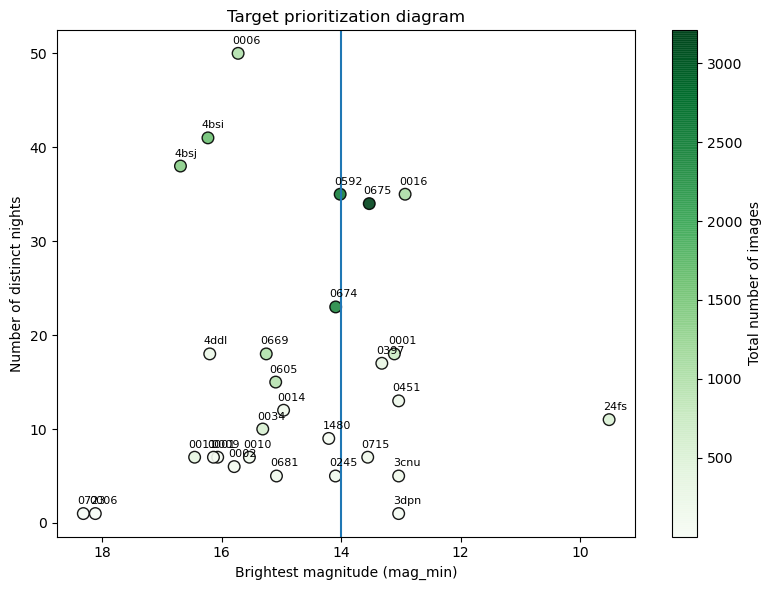

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# Eliminar posibles NaN
plot_df = priority_df.dropna(
    subset=["mag_min", "n_nights", "n_total_images"]
)

fig, ax = plt.subplots(figsize=(8,6))

# Normalización del color
norm = mcolors.Normalize(
    vmin=plot_df["n_total_images"].min(),
    vmax=plot_df["n_total_images"].max()
)

cmap = plt.get_cmap("Greens")

sc = ax.scatter(
    plot_df["mag_min"],
    plot_df["n_nights"],
    c=plot_df["n_total_images"],
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolor="black",
    alpha=0.9
)

# --------- ETIQUETAS ---------

for _, row in plot_df.iterrows():
    label = str(row["object"])[-4:]  # últimos 4 caracteres
    
    ax.text(
        row["mag_min"]+0.1,
        row["n_nights"]+0.8,
        label,
        fontsize=8,
        ha='left',
        va='bottom'
    )

# --------------------------------

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Total number of images")

ax.set_xlabel("Brightest magnitude (mag_min)")
ax.set_ylabel("Number of distinct nights")
ax.axvline(14)

ax.invert_xaxis()

ax.set_title("Target prioritization diagram")

plt.tight_layout()
plt.savefig("plots/priority_scatter.png", dpi=300)
plt.show()